In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd 

from pprint import pprint
import matplotlib.pyplot as plt

import os

import umap

In [58]:
normalized_data_path = os.path.join("data", "lego_normalized_features.csv")
normalized_data = pd.read_csv(normalized_data_path)


In [61]:
feature_cols = [
    "num_parts", "total_part_count", "unique_part_count", "minifig_count",
    "spare_part_ratio", "h_cat", "h_col", "n_distinct_colors",
    "n_distinct_categories", "prop_technic", "prop_printed", "prop_transparent",
    "rare_part_ratio", "minifig_to_part_ratio", "has_minifigs",
]

features = normalized_data[feature_cols].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
vif_data.sort_values("VIF", ascending=False)

independent_feature_cols = ["num_parts", "unique_part_count", "minifig_count", 
                "spare_part_ratio", "h_cat", "h_col", 
                "prop_technic", "prop_printed", "prop_transparent", 
                "rare_part_ratio", "minifig_to_part_ratio", "has_minifigs"]

independent_features = normalized_data[independent_feature_cols].dropna()

id_vif_data = pd.DataFrame()
id_vif_data["feature"] = independent_features.columns
id_vif_data["VIF"] = [variance_inflation_factor(independent_features.values, i) for i in range(independent_features.shape[1])]
id_vif_data.sort_values("VIF", ascending=False)

pprint(vif_data)
pprint(id_vif_data)



                  feature          VIF
0               num_parts  7217.750094
1        total_part_count  7094.148856
2       unique_part_count    11.570409
3           minifig_count     4.740547
4        spare_part_ratio     1.261394
5                   h_cat     5.769223
6                   h_col     3.789677
7       n_distinct_colors     7.451821
8   n_distinct_categories    14.951731
9            prop_technic     1.186818
10           prop_printed     1.807966
11       prop_transparent     1.102379
12        rare_part_ratio     2.118574
13  minifig_to_part_ratio     1.168835
14           has_minifigs     1.363685
                  feature       VIF
0               num_parts  2.586191
1       unique_part_count  4.057481
2           minifig_count  1.718635
3        spare_part_ratio  1.199358
4                   h_cat  2.478656
5                   h_col  1.520092
6            prop_technic  1.172931
7            prop_printed  1.803437
8        prop_transparent  1.101653
9         rare_p

In [50]:
window_summary = normalized_data.groupby("window_index").agg(
    n_sets=("set_num", "count"),
    min_year=("year", "min"),
    max_year=("year", "max"),
).sort_values("min_year")

pd.set_option("display.max_rows", None)
print(window_summary)

              n_sets  min_year  max_year
window_index                            
0                 56      1955      1966
1                131      1967      1973
2                110      1974      1976
3                149      1977      1979
4                101      1980      1981
5                138      1982      1984
6                104      1985      1985
7                220      1986      1987
8                134      1988      1989
9                178      1990      1991
10               179      1992      1993
11               105      1994      1994
12               130      1995      1995
13               139      1996      1996
14               181      1997      1997
15               276      1998      1998
16               230      1999      1999
17               265      2000      2000
18               232      2001      2001
19               251      2002      2002
20               269      2003      2003
21               250      2004      2004
22              

/opt/anaconda3/envs/isye6740/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


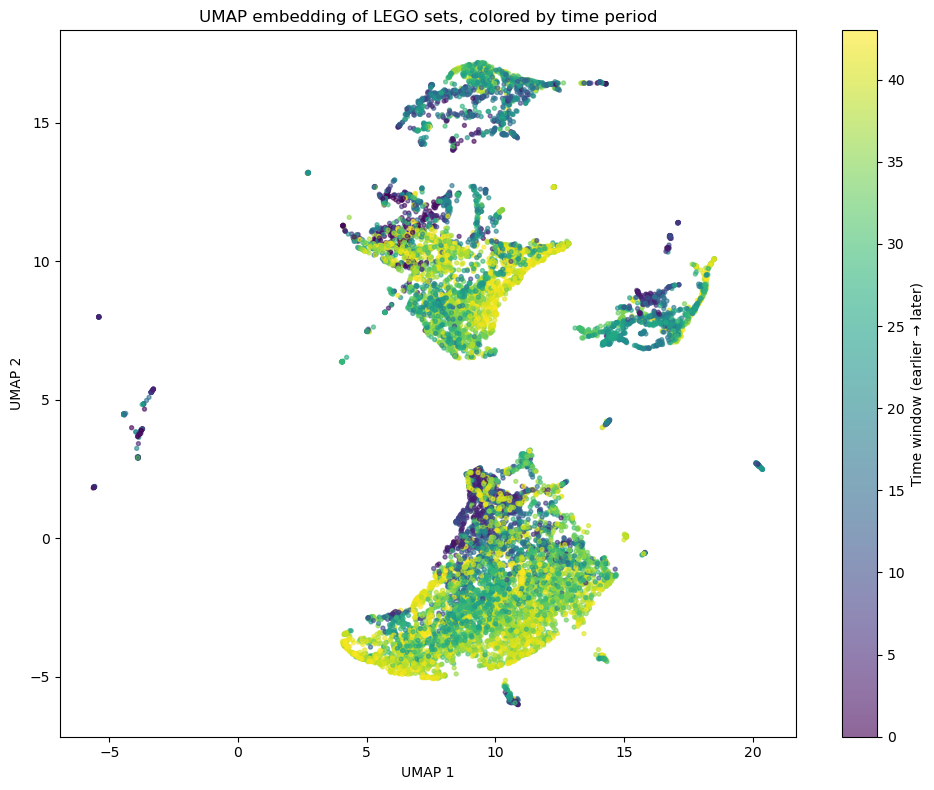

In [74]:
reducer = umap.UMAP(
    n_neighbors=15,      # local vs global structure tradeoff
    min_dist=0.1,        # how tightly points can pack together
    n_components=2,      # output dimensionality (2 for visualization)
    metric="euclidean",
    random_state=42,
)

embedding = reducer.fit_transform(normalized_data[independent_feature_cols])

normalized_data["umap_x"] = embedding[:, 0]
normalized_data["umap_y"] = embedding[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    normalized_data["umap_x"], normalized_data["umap_y"],
    c=normalized_data["window_index"],      # color by time window
    cmap="viridis",
    s=8,
    alpha=0.6,
)

plt.colorbar(scatter, label="Time window (earlier → later)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP embedding of LEGO sets, colored by time period")
plt.tight_layout()

output_file = os.path.join("outputs", "UMAP_embedding.png")
plt.savefig(output_file)

plt.show()